In [2]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('train_data.csv')
df_train, df_val = train_test_split(df, test_size=0.1)
len(df_train), len(df_val)

(720, 80)

In [4]:
x_train = df_train.iloc[:, 0:15]
x_val = df_val.iloc[:, 0:15]

In [5]:
scores = []
coeffs = []
for i in tqdm(range(15,1015)):
    y_train = df_train.iloc[:, i]
    y_val = df_val.iloc[:, i]
    model = LinearRegression()
    model.fit(x_train, y_train)
    preds = model.predict(x_val)
    coeffs.append(model.coef_)
    scores.append(mean_squared_error(y_val, preds))

100%|██████████| 1000/1000 [00:02<00:00, 416.51it/s]


(0.0, 0.2)

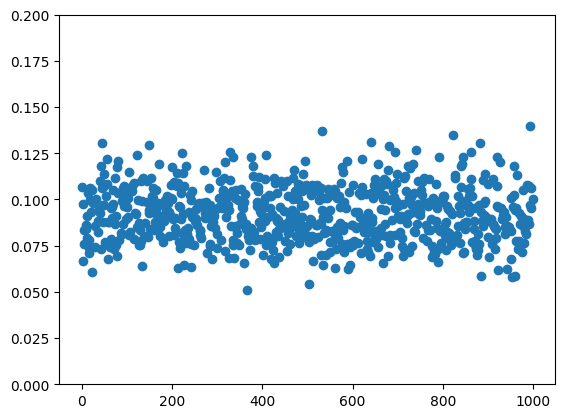

In [6]:
plt.scatter(range(0, 1000), scores)
plt.ylim(0, 0.2)

In [ ]:
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_coeffs = scaler.fit_transform(coeffs)
pca = UMAP(2)
pca_coeffs = pca.fit_transform(scaled_coeffs)
plt.scatter(pca_coeffs[:, 0], pca_coeffs[:, 1])


<Axes: >

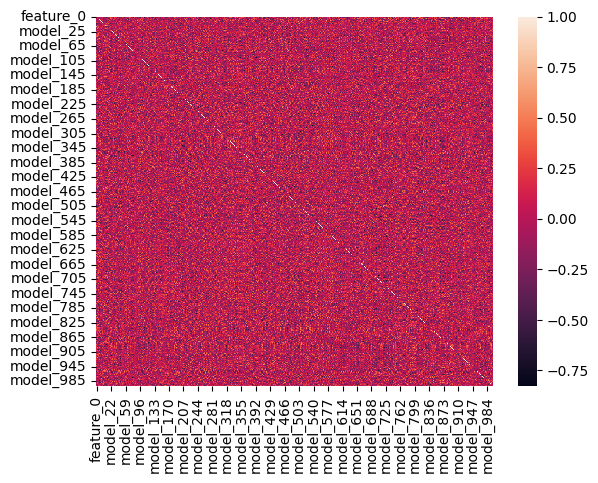

In [11]:
import seaborn as sns
corr = df_train.iloc[15:].corr()
sns.heatmap(corr)

In [21]:
pairs = corr.abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs<1.0][::2]
pairs[:10]

model_483  model_356    0.920509
model_181  model_483    0.917950
model_848  model_483    0.915943
model_356  model_11     0.914969
model_11   model_483    0.912885
model_848  model_356    0.911989
model_181  model_356    0.910617
model_11   model_181    0.909063
model_848  model_11     0.907256
model_181  model_848    0.905894
dtype: float64